In [1]:
import math
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image, ImageDraw
import matplotlib as mpl
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
import scipy.io as sio
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')
drive_dir = '/content/drive/MyDrive/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1) Generator for random-dot images
def generate_random_dot_image(img_size=(224,224), n_red=100, n_blue=90, dot_radius=4):
    width, height = img_size
    center = (width//2, height//2)
    radius = min(width, height)//2 - dot_radius
    min_dist_sq = (2*dot_radius)**2
    img = Image.new('RGB', img_size, 'white')
    draw = ImageDraw.Draw(img)
    centers = []
    def place(color, count):
        placed = 0
        attempts = 500
        while placed < count:
            for _ in range(attempts):
                x = random.randint(dot_radius, width-dot_radius)
                y = random.randint(dot_radius, height-dot_radius)
                if (x-center[0])**2 + (y-center[1])**2 > radius**2:
                    continue
                if any((x-cx)**2 + (y-cy)**2 < min_dist_sq for cx, cy in centers):
                    continue
                draw.ellipse([(x-dot_radius, y-dot_radius), (x+dot_radius, y+dot_radius)], fill=color)
                centers.append((x,y))
                placed += 1
                break
            else:
                raise RuntimeError(f"Could not place all {count} {color} dots.")
    place('red', n_red)
    place('blue', n_blue)
    return img

# 2) Generate Synthetic Dataset
class DotDataset(Dataset):
    def __init__(self, length, transform=None):
        self.length = length
        self.transform = transform
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        if idx % 2 == 0:
            img = generate_random_dot_image(n_red=100, n_blue=90)
            label = 0
        else:
            img = generate_random_dot_image(n_red=90, n_blue=100)
            label = 1
        if self.transform:
            img = self.transform(img)
        return img, label


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [ ]:
# Load & modify ANN:
from torchvision.models import AlexNet_Weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, 2)  # 2-way head
model.to(device)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:04<00:00, 54.5MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
# Generate Training Data
train_ds = DotDataset(length=100000, transform=transform)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# Freeze only convolutional features, allow entire classifier MLP to train
for name, param in model.named_parameters():
    if name.startswith('features'):
        param.requires_grad = False
    else:
        param.requires_grad = True

# Loss & optimizer (include all classifier parameters)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# Training loop
model.train()
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    epoch_loss = running_loss / len(train_ds)
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {epoch_loss:.4f}")

print("✅ Training complete. All classifier (MLP) layers were trainable.")

# Save Model
save_dir = '/content/drive/MyDrive/AlexNet_Images'
os.makedirs(save_dir, exist_ok=True)

full_path = os.path.join(save_dir, 'alexnet_finetuned_full_100k_ImgDuringTraining_mdl1.pth')
torch.save(model, full_path)
print(f"Full model saved to {full_path}")

In [ ]:
# Save the entire model
save_dir = '/content/drive/MyDrive/AlexNet_Images'
os.makedirs(save_dir, exist_ok=True)

full_path = os.path.join(save_dir, 'alexnet_finetuned_full_100k_ImgDuringTraining_mdl2.pth')
torch.save(model, full_path)
print(f"Full model saved to {full_path}")



In [ ]:
# Create Images for Testing (Only need to run once)
drive_dir    = '/content/drive/MyDrive/AlexNet_Images'
img_save_dir = os.path.join(drive_dir, 'test_images')
# print(img_save_dir)
# os.makedirs(img_save_dir, exist_ok=True)

for i in range(0,1000):

    if i % 2 == 0:
        img = generate_random_dot_image(n_red=100, n_blue=9)
    else:
        img = generate_random_dot_image(n_red=90,  n_blue=100)

    # **Save the raw image**
    img_path = os.path.join(img_save_dir, f'test_img_{i}.png')
    img.save(img_path)


In [ ]:
# Load Trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dir = '/content/drive/MyDrive/AlexNet_Images'


USE = "mdl1"

model2Load = f"alexnet_finetuned_full_100k_ImgDuringTraining_{USE}.pth"
full_path = os.path.join(model_dir, model2Load)
model = torch.load(full_path, map_location=device, weights_only=False)
model.eval()

print("✅ Model Loaded:", model2Load)


✅ Model Loaded: alexnet_finetuned_full_100k_ImgDuringTraining_mdl1.pth


In [ ]:
# ── Register hooks on fc layers 4, 5, & 6 to grab their activations ───────────
acts4, acts5, acts6  = {}, {},{}

model.classifier[4].register_forward_hook(
    lambda m, inp, out: acts4.update({'v': out.detach().cpu().numpy().squeeze()})
)

model.classifier[5].register_forward_hook(
    lambda m, inp, out: acts5.update({'v': out.detach().cpu().numpy().squeeze()})
)

model.classifier[6].register_forward_hook(
    lambda m, inp, out: acts6.update({'v': out.detach().cpu().numpy().squeeze()})
)


# ── Testing loop ─────────────────────────────────────────────────────────
model.eval()
results   = []
fc_4 = []
fc_5 = []
fc_6 = []

classes   = ['More red dots', 'More blue dots']

drive_dir    = '/content/drive/MyDrive/AlexNet_Images'
img_save_dir = os.path.join(drive_dir, 'test_images')
os.makedirs(img_save_dir, exist_ok=True)


for i in range(1000):

    if i % 100 == 0:
      print(i)

    # load image
    img_path = os.path.join(img_save_dir, f'test_img_{i}.png')
    img = Image.open(img_path).convert('RGB')

    if i % 2 == 0:
         gt = 0
    else:
         gt = 1

    inp   = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out   = model(inp)
        probs = F.softmax(out, dim=1)

    pred = probs.argmax(dim=1).item()
    conf = probs[0, pred].item()
    acc  = int(pred == gt)

    # collect activations from this forward pass
    fc_4.append(acts4['v'])
    fc_5.append(acts5['v'])
    fc_6.append(acts6['v'])

    results.append({
        'index':           i,
        'ground_truth':    classes[gt],
        'predicted_class': classes[pred],
        'confidence':      conf,
        'accuracy':        acc
    })

# ── Stack and save everything ────────────────────────────────────────────
fc_4_all = np.stack(fc_4, axis=0)
fc_5_all = np.stack(fc_5, axis=0)
fc_6_all = np.stack(fc_6, axis=0)
df        = pd.DataFrame(results)

drive_dir = '/content/drive/MyDrive/AlexNet_Images'
os.makedirs(drive_dir, exist_ok=True)

# Save features
sio.savemat(os.path.join(drive_dir, f"alexnet_{USE}_train_100K_test_1K_activation_cl_4_5_6.mat"), {
    'fc_4': fc_4_all,
    'fc_5': fc_5_all,
    'fc_6': fc_6_all
})


# Save performance
sio.savemat(os.path.join(drive_dir, f"alexnet_{USE}_train_100K_test_1K_performance_cl_4_5_6.mat"), {
    'index':           df['index'].values,
    'ground_truth':    df['ground_truth'].values,
    'predicted_class': df['predicted_class'].values,
    'confidence':      df['confidence'].values,
    'accuracy':        df['accuracy'].values
})

print("✅ Test complete: features and performance saved to", drive_dir)



0
100
200
300
400
500
600
700
800
900
0.51


In [ ]:
# Extract params (ensure `model` is defined and on CPU or GPU)
fc6w = model.classifier[6].weight.data.cpu().numpy()
fc6b = model.classifier[6].bias.data.cpu().numpy()


# Save to Drive (adjust path if needed)
save_path = f'/content/drive/MyDrive/AlexNet_Images/alexnet_{USE}_train_100K_weights_cl_4_5_6.mat'
sio.savemat(save_path, {
    'fc6w': fc6w,
    'fc6b': fc6b,

})

print(f"Saved fc parameters to {save_path}")


Saved fc parameters to /content/drive/MyDrive/AlexNet_Images/alexnet_mdl_4_train_100K_weights_cl_4_5_6.mat


In [ ]:
#---------------------------------------------------------------
# Estimate Layer-wise BDI On Binary Classifier (Red vs Blue Dot)
#---------------------------------------------------------------

def _get_conv_linear_layers(model: nn.Module):
    return [(name, m) for name, m in model.named_modules()
            if isinstance(m, (nn.Conv2d, nn.Linear))]

def _broadcast_bias(module: nn.Module, u: torch.Tensor) -> torch.Tensor:
    if getattr(module, "bias", None) is None or module.bias is None:
        return torch.zeros_like(u)
    b = module.bias
    if u.ndim == 2:      # Linear: (B, C)
        return b.view(1, -1).expand_as(u)
    if u.ndim == 4:      # Conv: (B, C, H, W)
        return b.view(1, -1, 1, 1).expand_as(u)
    return torch.zeros_like(u)

def multilayer_bdi_binary(
    model: nn.Module,
    x: torch.Tensor,
    y_true: torch.Tensor = None,              # (B,) long, optional
    margin_mode: str = "red_minus_blue",      # or "top1_minus_top2"
    red_class: int = 0,
    blue_class: int = 1,
    layers=None
):
    """
    Multi-layer BDI for binary classifiers using gradient×component at each affine layer.
    """
    model.eval()

    # IMPORTANT: make sure autograd can build a graph even if model params are frozen
    # (also avoids the retain_grad error)
    x = x.detach()
    x.requires_grad_(True)

    if layers is None:
        layers = _get_conv_linear_layers(model)

    store = {}
    hooks = []

    def make_hook(layer_name, layer_module):
        def hook_fn(m, inp, out):
            u = out
            # If this fails, you're still in inference_mode/no_grad.
            if not u.requires_grad:
                raise RuntimeError(
                    f"{layer_name} output has requires_grad=False. "
                    f"Make sure you're NOT using torch.inference_mode() / torch.no_grad()."
                )
            u.retain_grad()
            u_bias = _broadcast_bias(layer_module, u)
            store[layer_name] = {"u": u, "u_bias": u_bias}
        return hook_fn

    for name, m in layers:
        hooks.append(m.register_forward_hook(make_hook(name, m)))

    # Forward WITH grad
    z = model(x)  # expect (B,2)
    if z.ndim != 2 or z.shape[1] != 2:
        for h in hooks: h.remove()
        raise ValueError(f"Expected logits shape (B,2); got {tuple(z.shape)}")

    probs = torch.softmax(z, dim=1)
    pred = probs.argmax(dim=1)
    conf = probs.max(dim=1).values

    # Margin
    if margin_mode == "red_minus_blue":
        m = z[:, red_class] - z[:, blue_class]      # signed
    elif margin_mode == "top1_minus_top2":
        top2 = torch.topk(z, k=2, dim=1).values
        m = top2[:, 0] - top2[:, 1]                 # >= 0
    else:
        for h in hooks: h.remove()
        raise ValueError("margin_mode must be 'red_minus_blue' or 'top1_minus_top2'")

    model.zero_grad(set_to_none=True)
    m.sum().backward()

    bdi_by_layer = {}
    abs_bias_sum = None
    abs_evid_sum = None

    for name, _ in layers:
        u = store[name]["u"]
        u_bias = store[name]["u_bias"]
        g = u.grad

        u_evid = u - u_bias
        dims = tuple(range(1, u.ndim))

        C_bias = (g * u_bias).sum(dim=dims)   # (B,)
        C_evid = (g * u_evid).sum(dim=dims)   # (B,)

        denom = C_bias.abs() + C_evid.abs()
        bdi_l = torch.where(denom > 0, C_bias.abs() / denom, torch.full_like(denom, 0.5))
        bdi_by_layer[name] = bdi_l.detach()

        if abs_bias_sum is None:
            abs_bias_sum = C_bias.abs()
            abs_evid_sum = C_evid.abs()
        else:
            abs_bias_sum = abs_bias_sum + C_bias.abs()
            abs_evid_sum = abs_evid_sum + C_evid.abs()

    denom_all = abs_bias_sum + abs_evid_sum
    bdi_all = torch.where(denom_all > 0, abs_bias_sum / denom_all, torch.full_like(denom_all, 0.5))

    correct = None
    if y_true is not None:
        correct = (pred == y_true)

    for h in hooks:
        h.remove()

    return bdi_by_layer, bdi_all.detach(), z.detach(), pred.detach(), conf.detach(), correct


In [ ]:
import pandas as pd
import re

#----------------------------
# Run BDI on model
#----------------------------



def extract_last_int_from_path(p: str) -> int:
    base = os.path.splitext(os.path.basename(p))[0]
    nums = re.findall(r"\d+", base)
    if not nums:
        raise ValueError(f"No integer found in filename: {base}")
    return int(nums[-1])  # last integer token

# --- preprocessing: use whatever you used during training ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

img_save_dir = "/content/drive/MyDrive/AlexNet_Images/test_images"  # adjust
all_imgs = sorted(glob.glob(os.path.join(img_save_dir, "*.png")))
print("N images:", len(all_imgs))

BATCH = 10
layers = _get_conv_linear_layers(model)
layer_names = [n for n, _ in layers]

# accumulators
bdi_layers_accum = {name: [] for name in layer_names}
bdi_all_accum = []
pred_accum = []
conf_accum = []
correct_accum = []

for i in range(0, len(all_imgs), BATCH):
    paths = all_imgs[i:i+BATCH]

    imgs = []
    y = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        imgs.append(transform(img))

        # ground truth rule (edit if different):
        # even index -> red(0), odd -> blue(1)
        idx = extract_last_int_from_path(p)
        y.append(0 if (idx % 2 == 0) else 1)

    x = torch.stack(imgs, dim=0).to(device)
    y_true = torch.tensor(y, dtype=torch.long, device=device)

    bdi_by_layer, bdi_all, z, pred, conf, correct = multilayer_bdi_binary(
        model, x, y_true=y_true,
        margin_mode="red_minus_blue",   # or "top1_minus_top2"
        red_class=0, blue_class=1,
        layers=layers
    )

    for name in layer_names:
        bdi_layers_accum[name].append(bdi_by_layer[name].cpu().numpy())
    bdi_all_accum.append(bdi_all.cpu().numpy())
    pred_accum.append(pred.cpu().numpy())
    conf_accum.append(conf.cpu().numpy())
    correct_accum.append(correct.cpu().numpy())

# stack to (N,)
bdi_all_np = np.concatenate(bdi_all_accum, axis=0)
pred_np = np.concatenate(pred_accum, axis=0)
conf_np = np.concatenate(conf_accum, axis=0)
correct_np = np.concatenate(correct_accum, axis=0)

bdi_layers_np = {name: np.concatenate(chunks, axis=0) for name, chunks in bdi_layers_accum.items()}

print("BDI all layers:", bdi_all_np.shape)
print("Accuracy:", correct_np.mean(), f"({correct_np.sum()}/{correct_np.size})")

# ----------------------------
# Save to CSV (one row per image)
# ----------------------------


out_dir = "/content/drive/MyDrive/AlexNet_Images"
os.makedirs(out_dir, exist_ok=True)

# base columns
df = pd.DataFrame({
    "bdi_all_layers": bdi_all_np.astype(float),
    "pred": pred_np.astype(int),
    "conf": conf_np.astype(float),
    "correct": correct_np.astype(int),
})

# add per-layer columns
for name, arr in bdi_layers_np.items():
    col = "bdi_" + name.replace(".", "_")
    df[col] = np.asarray(arr).astype(float)

csv_path = os.path.join(out_dir, f"{USE}_multilayer_bdi_redblue.csv")
df.to_csv(csv_path, index=False)

print("✅ Saved CSV:", csv_path)
print("CSV shape:", df.shape)



N images: 1000
BDI all layers: (1000,)
Accuracy: 0.741 (741/1000)
✅ Saved CSV: /content/drive/MyDrive/AlexNet_Images/mdl4_multilayer_bdi_redblue.csv
CSV shape: (1000, 12)


Loaded: /content/drive/MyDrive/AlexNet_Images/mdl5_multilayer_bdi_redblue.csv
Shape: (1000, 12)
Saved: /content/drive/MyDrive/AlexNet_Images/mdl5_BDI_all_layers_sorted.eps


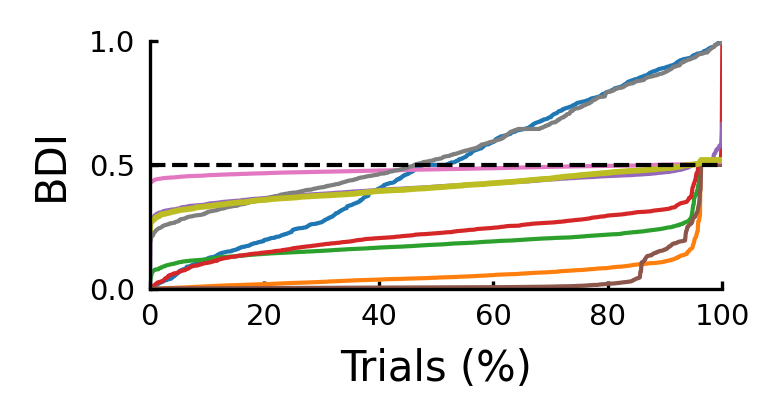

In [ ]:
import os, re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ----------------------------
# Load
# ----------------------------
USE = "mdl5"
out_dir = "/content/drive/MyDrive/AlexNet_Images"
csv_path = os.path.join(out_dir, f"{USE}_multilayer_bdi_redblue.csv")

df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", df.shape)

# ----------------------------
# Plot styling
# ----------------------------
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
mpl.set_loglevel("error")

# ----------------------------
# Collect BDI columns (your schema: bdi_<layername>)
# ----------------------------
bdi_cols = [c for c in df.columns if c.startswith("bdi_") and c != "bdi_all_layers"]
if len(bdi_cols) == 0:
    raise ValueError("No per-layer BDI columns found (expected columns starting with 'bdi_').")

# Optional: include all-layers curve too
include_all_layers = "bdi_all_layers" in df.columns

# ----------------------------
# Order layers: features -> classifier (ascending indices)
# ----------------------------
def layer_sort_key(col: str):
    s = col.lower()
    # group: features first, then classifier, then anything else
    if "features" in s:
        group = 0
    elif "classifier" in s or re.search(r"\bfc\b", s):
        group = 1
    else:
        group = 2

    nums = re.findall(r"\d+", col)
    last_num = int(nums[-1]) if nums else 10**9
    return (group, last_num, col)

bdi_cols = sorted(bdi_cols, key=layer_sort_key)

# ----------------------------
# Plot: sorted BDI within each layer (x = percent trials)
# ----------------------------
n_show = 1000          # cap number of points per layer (after sorting)
sort_each_layer = True
save_fig = True
save_path = os.path.join(out_dir, f"{USE}_BDI_all_layers_sorted.eps")

fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

for col in bdi_cols:
    bdi = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
    bdi = bdi[np.isfinite(bdi)]
    if bdi.size == 0:
        continue

    if sort_each_layer:
        bdi = np.sort(bdi)

    n = min(n_show, bdi.size)
    bdi = bdi[:n]

    if sort_each_layer:
        x = (np.arange(1, n + 1) / n) * 100.0  # percent trials
    else:
        x = np.arange(1, n + 1)

    ax.plot(x, bdi, linewidth=1, alpha=1)

# Optional: add all-layers curve
if include_all_layers:
    bdi = pd.to_numeric(df["bdi_all_layers"], errors="coerce").to_numpy(dtype=float)
    bdi = bdi[np.isfinite(bdi)]
    if bdi.size:
        if sort_each_layer:
            bdi = np.sort(bdi)
        n = min(n_show, bdi.size)
        bdi = bdi[:n]
        x = (np.arange(1, n + 1) / n) * 100.0 if sort_each_layer else np.arange(1, n + 1)
        ax.plot(x, bdi, linewidth=1.4, alpha=1)

ax.axhline(0.5, linestyle="--", color="black", linewidth=1)

if sort_each_layer:
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
    ax.set_xlabel("Trials (%)", fontsize=10)
else:
    ax.set_xlim(1, n_show)
    ax.set_xlabel("Trials", fontsize=10)

ax.set_yticks([0, 0.5, 1])
ax.set_ylim(0, 1)
ax.set_ylabel("BDI", fontsize=10)
# ax.set_title("Layer-wise BDI (sorted within layer)", fontsize=10)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis="y", which="both", direction="in", left=True, right=False, length=2, labelsize=7)
ax.tick_params(axis="x", which="both", direction="in", length=2, labelsize=7)

fig.tight_layout()

if save_fig:
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.02)
    print("Saved:", save_path)

plt.show()


# New Section

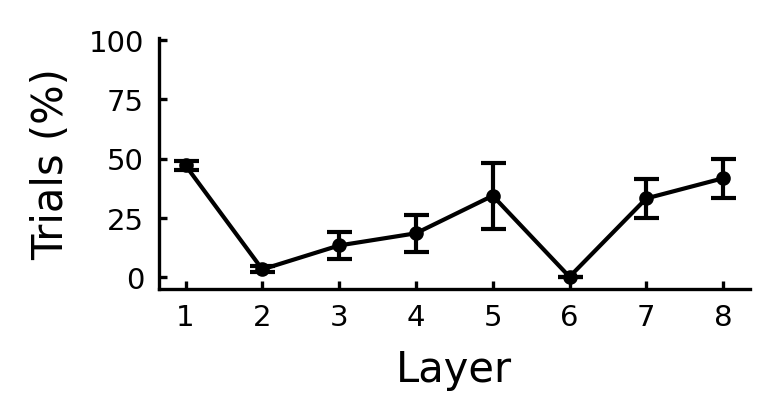

In [ ]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

out_dir = "/content/drive/MyDrive/AlexNet_Images"

# ---- load the 5 model CSVs ----
csv_paths = sorted(glob.glob(os.path.join(out_dir, "*_multilayer_bdi_redblue.csv")))
if len(csv_paths) != 5:
    print("Found:", len(csv_paths))
    print("\n".join([os.path.basename(p) for p in csv_paths]))
    raise ValueError("Expected 5 CSVs. Adjust out_dir or pattern, or filter to your 5 files.")

def get_use_from_path(path: str) -> str:
    return os.path.basename(path).replace("_multilayer_bdi_redblue.csv", "")

def layer_sort_key(colname: str):
    s = colname.replace("bdi_", "").replace(".", "_")
    m = re.match(r"^(features|classifier)_(\d+)$", s)
    if m:
        block, idx = m.group(1), int(m.group(2))
        group = 0 if block == "features" else 1
        return (group, idx, s)
    nums = re.findall(r"\d+", s)
    first_num = int(nums[0]) if nums else 10**9
    return (2, first_num, s)

# ---- per model: compute % trials with BDI>0.5 per layer ----
per_model = {}          # USE -> Series(layer_col -> pct_gt05)
common_layer_cols = None

for path in csv_paths:
    USE = get_use_from_path(path)
    df = pd.read_csv(path)

    layer_cols = [c for c in df.columns if c.startswith("bdi_") and c != "bdi_all_layers"]
    layer_cols = sorted(layer_cols, key=layer_sort_key)

    if common_layer_cols is None:
        common_layer_cols = set(layer_cols)
    else:
        common_layer_cols &= set(layer_cols)

    pct = {}
    for c in layer_cols:
        x = df[c].to_numpy(dtype=float)
        x = x[np.isfinite(x)]
        pct[c] = 100.0 * np.mean(x > 0.5) if x.size else np.nan

    per_model[USE] = pd.Series(pct, name=USE)

common_layer_cols = sorted(list(common_layer_cols), key=layer_sort_key)
if not common_layer_cols:
    raise RuntimeError("No common bdi_<layer> columns across the 5 models (exact name match).")

# ---- Build table AFTER loop (rows=layers, cols=models) ----
pct_table = pd.DataFrame({m: s.reindex(common_layer_cols) for m, s in per_model.items()})

# ---- mean + SEM across models ----
N = pct_table.shape[1]  # should be 5
mean_pct = pct_table.mean(axis=1)
std_pct  = pct_table.std(axis=1, ddof=1)
sem_pct  = std_pct / np.sqrt(N)

# ---- choose how many layers to show ----
K = 8
K = min(K, len(common_layer_cols))

x = np.arange(K)
y = mean_pct.to_numpy()[:K]
yerr = sem_pct.to_numpy()[:K]

# ---- plot ----
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)
ax.errorbar(x, y, yerr=yerr, fmt='-o', linewidth=1, markersize=2.5,
            capsize=3, color='black')

ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in range(1, K+1)], fontsize=7)

ax.set_ylabel("Trials (%)", fontsize=10)
ax.set_xlabel("Layer", fontsize=10)

ax.set_ylim(-5, 101)
ax.set_yticks(np.arange(0, 101, 25))
ax.tick_params(axis='y', labelsize=7)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='x', which='both', direction='in', length=2)
ax.tick_params(axis='y', which='both', direction='in', left=True, right=False, length=2)

fig.tight_layout()

fig.savefig(os.path.join(out_dir, "Dot_Task_BDI_pct_gt05_per_layer.eps"),
             dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()



Processing: mdl1
CSV: /content/drive/MyDrive/AlexNet_Images/mdl1_multilayer_bdi_redblue.csv
Shape: (1000, 22)
N layer columns: 8
First layers: ['bdi_features_0', 'bdi_features_3', 'bdi_features_6', 'bdi_features_8', 'bdi_features_10']
Last layer: bdi_classifier_6
Saved: /content/drive/MyDrive/AlexNet_Images/mdl1_BDI_all_layers_sorted_groupcolors.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl1_BDI_all_layers_sorted_groupcolors.png


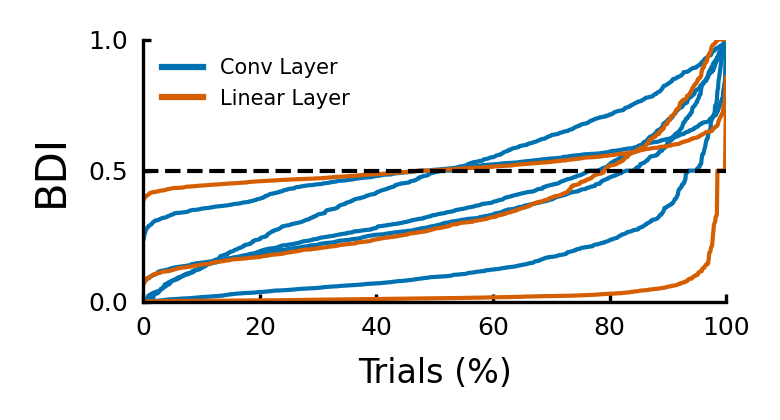


Processing: mdl2
CSV: /content/drive/MyDrive/AlexNet_Images/mdl2_multilayer_bdi_redblue.csv
Shape: (1000, 22)
N layer columns: 8
First layers: ['bdi_features_0', 'bdi_features_3', 'bdi_features_6', 'bdi_features_8', 'bdi_features_10']
Last layer: bdi_classifier_6
Saved: /content/drive/MyDrive/AlexNet_Images/mdl2_BDI_all_layers_sorted_groupcolors.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl2_BDI_all_layers_sorted_groupcolors.png


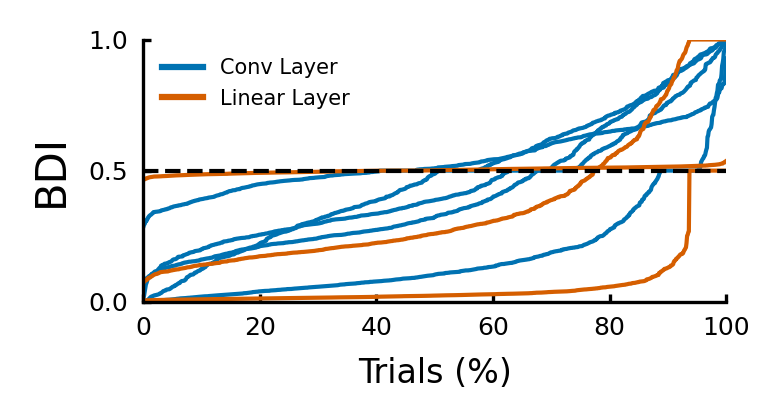


Processing: mdl3
CSV: /content/drive/MyDrive/AlexNet_Images/mdl3_multilayer_bdi_redblue.csv
Shape: (1000, 22)
N layer columns: 8
First layers: ['bdi_features_0', 'bdi_features_3', 'bdi_features_6', 'bdi_features_8', 'bdi_features_10']
Last layer: bdi_classifier_6
Saved: /content/drive/MyDrive/AlexNet_Images/mdl3_BDI_all_layers_sorted_groupcolors.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl3_BDI_all_layers_sorted_groupcolors.png


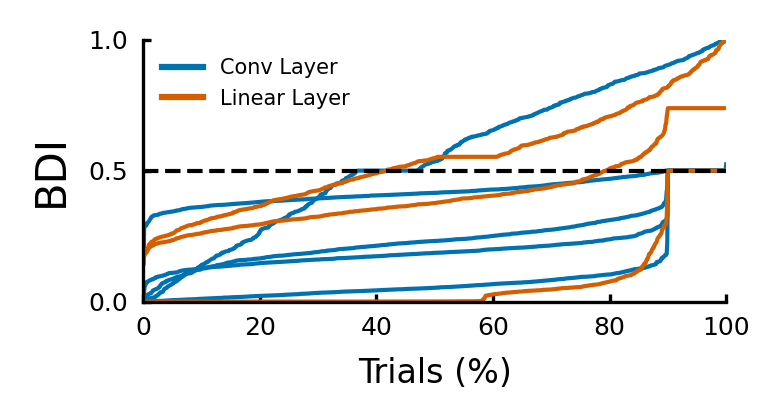


Processing: mdl4
CSV: /content/drive/MyDrive/AlexNet_Images/mdl4_multilayer_bdi_redblue.csv
Shape: (1000, 22)
N layer columns: 8
First layers: ['bdi_features_0', 'bdi_features_3', 'bdi_features_6', 'bdi_features_8', 'bdi_features_10']
Last layer: bdi_classifier_6
Saved: /content/drive/MyDrive/AlexNet_Images/mdl4_BDI_all_layers_sorted_groupcolors.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl4_BDI_all_layers_sorted_groupcolors.png


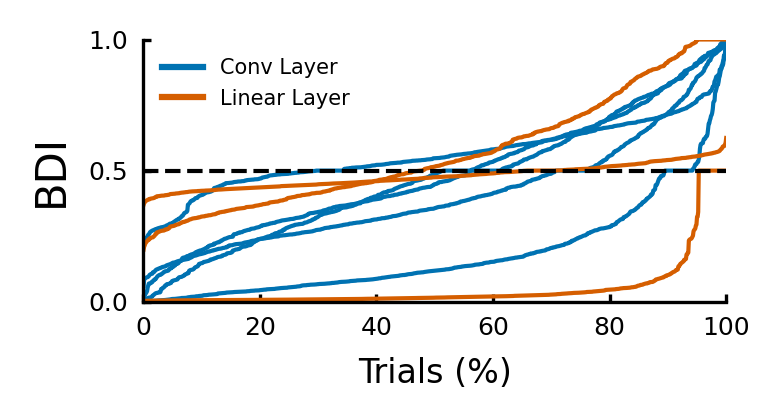


Processing: mdl5
CSV: /content/drive/MyDrive/AlexNet_Images/mdl5_multilayer_bdi_redblue.csv
Shape: (1000, 22)
N layer columns: 8
First layers: ['bdi_features_0', 'bdi_features_3', 'bdi_features_6', 'bdi_features_8', 'bdi_features_10']
Last layer: bdi_classifier_6
Saved: /content/drive/MyDrive/AlexNet_Images/mdl5_BDI_all_layers_sorted_groupcolors.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl5_BDI_all_layers_sorted_groupcolors.png


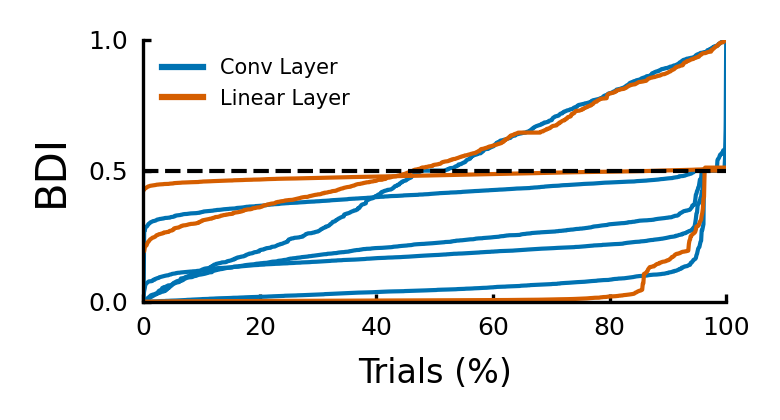

Saved: /content/drive/MyDrive/AlexNet_Images/Dot_Task_BDI_pct_gt05_per_layer_by_model.csv
Saved: /content/drive/MyDrive/AlexNet_Images/Dot_Task_BDI_pct_gt05_per_layer_meanSEM_groupcolors.eps
Saved: /content/drive/MyDrive/AlexNet_Images/Dot_Task_BDI_pct_gt05_per_layer_meanSEM_groupcolors.png


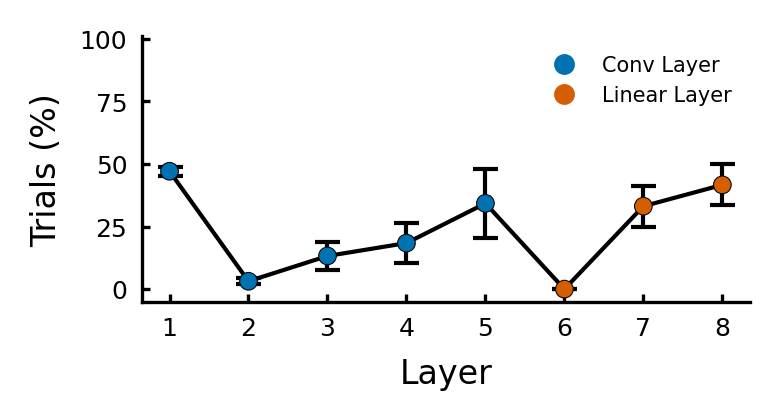


Aggregate layer summary:


,layer,mean_pct_gt05,sem_pct_gt05
0,bdi_features_0,47.10,1.820165
1,bdi_features_3,3.18,1.286623
2,bdi_features_6,13.28,5.653530
3,bdi_features_8,18.42,7.893567
4,bdi_features_10,34.28,13.857828
5,bdi_classifier_1,0.04,0.040000
6,bdi_classifier_4,33.14,8.203207
7,bdi_classifier_6,41.66,8.148902


In [14]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Settings
# ============================================================
save_fig = True
out_dir = "/content/drive/MyDrive/AlexNet_Images"

csv_paths = sorted(glob.glob(os.path.join(out_dir, "*_multilayer_bdi_redblue.csv")))

if len(csv_paths) != 5:
    print("Found:", len(csv_paths))
    print("\n".join([os.path.basename(p) for p in csv_paths]))
    raise ValueError("Expected 5 CSVs. Adjust out_dir/pattern or manually filter to your 5 files.")

# Plot options
n_show = 1000
sort_each_layer = True
show_legend = True

# Aggregate plot options
K = 8   # number of common layers to show in aggregate mean ± SEM plot

# ============================================================
# Plot styling
# ============================================================
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
mpl.set_loglevel("error")

# Color-blind friendly colors
FEATURE_COLOR = "#0072B2"       # blue
CLASSIFIER_COLOR = "#D55E00"    # vermillion / orange
OTHER_COLOR = "#7F7F7F"         # gray


# ============================================================
# Helper functions
# ============================================================
def get_use_from_path(path: str) -> str:
    return os.path.basename(path).replace("_multilayer_bdi_redblue.csv", "")


def layer_sort_key(col: str):
    """
    Sort order:
      1. features / convolutional layers
      2. classifier / linear layers
      3. other
    """
    s = col.lower().replace("bdi_", "").replace(".", "_")

    m = re.match(r"^(features|classifier)_(\d+)$", s)
    if m:
        block, idx = m.group(1), int(m.group(2))
        group = 0 if block == "features" else 1
        return (group, idx, s)

    if "features" in s:
        group = 0
    elif "classifier" in s or re.search(r"(^|_)fc($|_|\d)", s):
        group = 1
    else:
        group = 2

    nums = re.findall(r"\d+", s)
    last_num = int(nums[-1]) if nums else 10**9

    return (group, last_num, s)


def layer_group(col: str):
    s = col.lower().replace("bdi_", "").replace(".", "_")

    if "features" in s:
        return "features"
    elif "classifier" in s or re.search(r"(^|_)fc($|_|\d)", s):
        return "classifier"
    else:
        return "other"


def layer_color(col: str):
    g = layer_group(col)

    if g == "features":
        return FEATURE_COLOR
    elif g == "classifier":
        return CLASSIFIER_COLOR
    else:
        return OTHER_COLOR


def get_layer_cols(df):
    cols = [
        c for c in df.columns
        if c.startswith("bdi_") and c != "bdi_all_layers"
    ]
    return sorted(cols, key=layer_sort_key)


# ============================================================
# Containers for aggregate analysis
# ============================================================
per_model_pct = {}
common_layer_cols = None


# ============================================================
# Part 1: Iterate over five models and make individual plots
# ============================================================
for csv_path in csv_paths:

    USE = get_use_from_path(csv_path)

    print("\n============================================================")
    print("Processing:", USE)
    print("CSV:", csv_path)
    print("============================================================")

    df = pd.read_csv(csv_path)
    print("Shape:", df.shape)

    layer_cols = get_layer_cols(df)

    if len(layer_cols) == 0:
        raise ValueError(f"{USE}: no per-layer BDI columns found.")

    print("N layer columns:", len(layer_cols))
    print("First layers:", layer_cols[:5])
    print("Last layer:", layer_cols[-1])

    # --------------------------------------------------------
    # Store per-layer % BDI > 0.5 for aggregate plot
    # --------------------------------------------------------
    if common_layer_cols is None:
        common_layer_cols = set(layer_cols)
    else:
        common_layer_cols &= set(layer_cols)

    pct = {}

    for c in layer_cols:
        vals = pd.to_numeric(df[c], errors="coerce").to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        pct[c] = 100.0 * np.mean(vals > 0.5) if vals.size else np.nan

    per_model_pct[USE] = pd.Series(pct, name=USE)

    # --------------------------------------------------------
    # Individual layerwise BDI curve plot
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

    for col in layer_cols:
        bdi = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
        bdi = bdi[np.isfinite(bdi)]

        if bdi.size == 0:
            continue

        if sort_each_layer:
            bdi = np.sort(bdi)

        n = min(n_show, bdi.size)
        bdi = bdi[:n]

        if sort_each_layer:
            x = (np.arange(1, n + 1) / n) * 100.0
        else:
            x = np.arange(1, n + 1)

        ax.plot(
            x,
            bdi,
            linewidth=1,
            alpha=1,
            color=layer_color(col),
        )

    # Axes
    ax.axhline(0.5, linestyle="--", color="black", linewidth=1)

    if sort_each_layer:
        ax.set_xlim(0, 100)
        ax.set_xticks(np.arange(0, 101, 20))
        ax.set_xlabel("Trials (%)", fontsize=8)
    else:
        ax.set_xlim(1, n_show)
        ax.set_xlabel("Trials", fontsize=8)

    ax.set_yticks([0, 0.5, 1])
    ax.set_ylim(0, 1)
    ax.set_ylabel("BDI", fontsize=10)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.tick_params(
        axis="y",
        which="both",
        direction="in",
        left=True,
        right=False,
        length=2,
        labelsize=6,
    )

    ax.tick_params(
        axis="x",
        which="both",
        direction="in",
        length=2,
        labelsize=6,
    )

    # Legend
    if show_legend:
        legend_handles = [
            Line2D([0], [0], color=FEATURE_COLOR, lw=1.5, label="Conv Layer"),
            Line2D([0], [0], color=CLASSIFIER_COLOR, lw=1.5, label="Linear Layer"),
        ]

        if any(layer_group(c) == "other" for c in layer_cols):
            legend_handles.append(
                Line2D([0], [0], color=OTHER_COLOR, lw=1.5, label="Other")
            )

        ax.legend(
            handles=legend_handles,
            fontsize=5,
            frameon=False,
            loc="upper left",
        )

    fig.tight_layout()

    # Save individual plot
    if save_fig:
        save_base = os.path.join(
            out_dir,
            f"{USE}_BDI_all_layers_sorted_groupcolors"
        )

        fig.savefig(
            save_base + ".eps",
            format="eps",
            bbox_inches="tight",
            pad_inches=0.02,
        )

        fig.savefig(
            save_base + ".png",
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.02,
        )

        print("Saved:", save_base + ".eps")
        print("Saved:", save_base + ".png")

    plt.show()


# ============================================================
# Part 2: Aggregate across five models
# Mean ± SEM of % trials with BDI > 0.5 per common layer
# ============================================================
common_layer_cols = sorted(list(common_layer_cols), key=layer_sort_key)

if len(common_layer_cols) == 0:
    raise RuntimeError("No common bdi_<layer> columns across the 5 models.")

pct_table = pd.DataFrame({
    model: series.reindex(common_layer_cols)
    for model, series in per_model_pct.items()
})

# Save aggregate table
pct_table_path = os.path.join(out_dir, "Dot_Task_BDI_pct_gt05_per_layer_by_model.csv")
pct_table.to_csv(pct_table_path)
print("Saved:", pct_table_path)

# Mean + SEM across models
n_models = pct_table.shape[1]
mean_pct = pct_table.mean(axis=1)
std_pct = pct_table.std(axis=1, ddof=1)
sem_pct = std_pct / np.sqrt(n_models)

K = min(K, len(common_layer_cols))

x = np.arange(K)
y = mean_pct.to_numpy()[:K]
yerr = sem_pct.to_numpy()[:K]

layer_cols_K = common_layer_cols[:K]
point_colors = [layer_color(c) for c in layer_cols_K]

# ------------------------------------------------------------
# Aggregate plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

ax.plot(
    x,
    y,
    linestyle="-",
    linewidth=1,
    color="black",
    zorder=1,
)

ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="none",
    linewidth=1,
    capsize=3,
    color="black",
    zorder=2,
)

ax.scatter(
    x,
    y,
    c=point_colors,
    s=18,
    edgecolor="black",
    linewidth=0.25,
    zorder=3,
)

ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in range(1, K + 1)], fontsize=7)

ax.set_ylabel("Trials (%)", fontsize=8)
ax.set_xlabel("Layer", fontsize=8)

ax.set_ylim(-5, 101)
ax.set_yticks(np.arange(0, 101, 25))

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.tick_params(
    axis="x",
    which="both",
    direction="in",
    length=2,
    labelsize=6,
)

ax.tick_params(
    axis="y",
    which="both",
    direction="in",
    left=True,
    right=False,
    length=2,
    labelsize=6,
)

# Legend for aggregate plot
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=FEATURE_COLOR,
        markeredgecolor=FEATURE_COLOR,
        markersize=4,
        label="Conv Layer",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=CLASSIFIER_COLOR,
        markeredgecolor=CLASSIFIER_COLOR,
        markersize=4,
        label="Linear Layer",
    ),
]

if any(layer_group(c) == "other" for c in layer_cols_K):
    legend_handles.append(
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=OTHER_COLOR,
            markeredgecolor=OTHER_COLOR,
            markersize=4,
            label="Other",
        )
    )

ax.legend(
    handles=legend_handles,
    fontsize=5,
    frameon=False,
    loc="best",
)

fig.tight_layout()

if save_fig:
    save_base = os.path.join(out_dir, "Dot_Task_BDI_pct_gt05_per_layer_meanSEM_groupcolors")

    fig.savefig(
        save_base + ".eps",
        format="eps",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.02,
    )

    fig.savefig(
        save_base + ".png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02,
    )

    print("Saved:", save_base + ".eps")
    print("Saved:", save_base + ".png")

plt.show()

print("\nAggregate layer summary:")
summary = pd.DataFrame({
    "layer": common_layer_cols,
    "mean_pct_gt05": mean_pct.values,
    "sem_pct_gt05": sem_pct.values,
})
display(summary.head(K))

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

# pct_table: rows=layers, cols=models, values=% trials with BDI>0.5

H0 = 0.0  # set to 50.0 if you mean "majority of trials"
rows = []

for layer in pct_table.index:  # or common_layer_cols
    vals = pct_table.loc[layer].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    n = vals.size

    if n < 2:
        rows.append((layer, n, np.nan, np.nan, np.nan, np.nan))
        continue

    t_stat, p_two = stats.ttest_1samp(vals, popmean=H0)

    # one-sided p-value for H1: mean > H0
    p_one = (p_two / 2) if (t_stat > 0) else (1 - p_two / 2)

    mean_val = float(np.mean(vals))
    sem_val  = float(np.std(vals, ddof=1) / np.sqrt(n))

    rows.append((layer, n, mean_val, sem_val, float(t_stat), float(p_one)))

tt_layer = pd.DataFrame(
    rows,
    columns=["layer", "n_models", "mean_pct", "sem_pct", "t", "p_one_sided_mean_gt_H0"]
)

# clean layer names if you want
tt_layer["layer"] = tt_layer["layer"].astype(str).str.replace("^bdi_", "", regex=True)

# ---- FDR-BH correction on valid p-values ----
p = tt_layer["p_one_sided_mean_gt_H0"].to_numpy(dtype=float)
valid = np.isfinite(p)

tt_layer["p_fdr_bh"] = np.nan
tt_layer["sig_fdr_0p05"] = False

rej, p_fdr, _, _ = multipletests(p[valid], alpha=0.05, method="fdr_bh")
tt_layer.loc[valid, "p_fdr_bh"] = p_fdr
tt_layer.loc[valid, "sig_fdr_0p05"] = rej

print(tt_layer)


          layer  n_models  mean_pct    sem_pct          t  \
0    features_0         5     47.10   1.820165  25.876777   
1    features_3         5      3.18   1.286623   2.471586   
2    features_6         5     13.28   5.653530   2.348975   
3    features_8         5     18.42   7.893567   2.333546   
4   features_10         5     34.28  13.857828   2.473692   
5  classifier_1         5      0.04   0.040000   1.000000   
6  classifier_4         5     33.14   8.203207   4.039884   
7  classifier_6         5     41.66   8.148902   5.112345   

   p_one_sided_mean_gt_H0  p_fdr_bh  sig_fdr_0p05  
0                0.000007  0.000053          True  
1                0.034415  0.045681          True  
2                0.039302  0.045681          True  
3                0.039971  0.045681          True  
4                0.034337  0.045681          True  
5                0.186950  0.186950         False  
6                0.007803  0.020807          True  
7                0.003461  0.01384

Saved: /content/drive/MyDrive/AlexNet_Images/mdl1_BDI_last_layer_vs_conf_colored_correct_marginal_hist.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl1_BDI_last_layer_vs_conf_colored_correct_marginal_hist.png


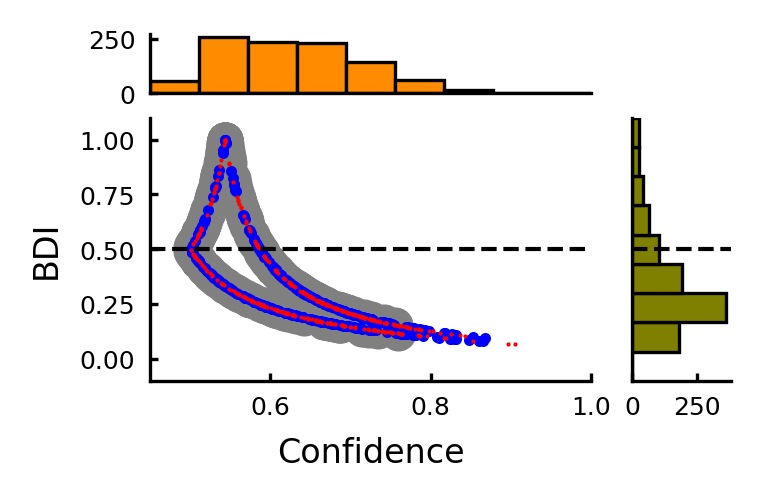

mdl1: last_layer_col=bdi_classifier_6, n_points=1000, acc=0.7420
Saved: /content/drive/MyDrive/AlexNet_Images/mdl2_BDI_last_layer_vs_conf_colored_correct_marginal_hist.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl2_BDI_last_layer_vs_conf_colored_correct_marginal_hist.png


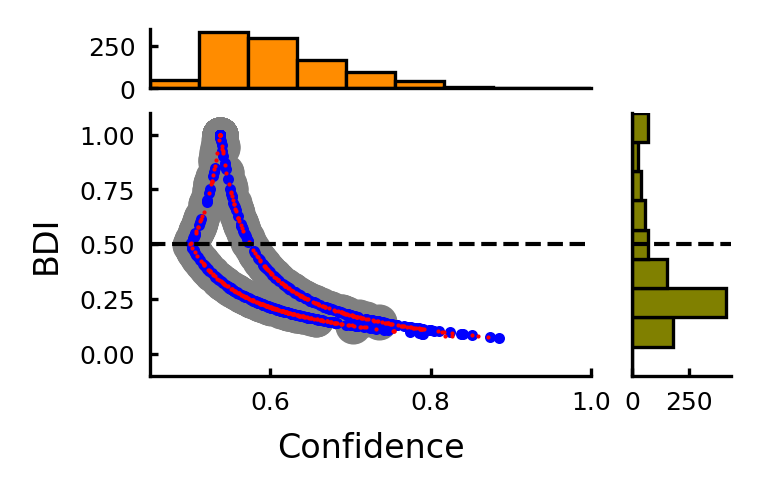

mdl2: last_layer_col=bdi_classifier_6, n_points=1000, acc=0.7550
Saved: /content/drive/MyDrive/AlexNet_Images/mdl3_BDI_last_layer_vs_conf_colored_correct_marginal_hist.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl3_BDI_last_layer_vs_conf_colored_correct_marginal_hist.png


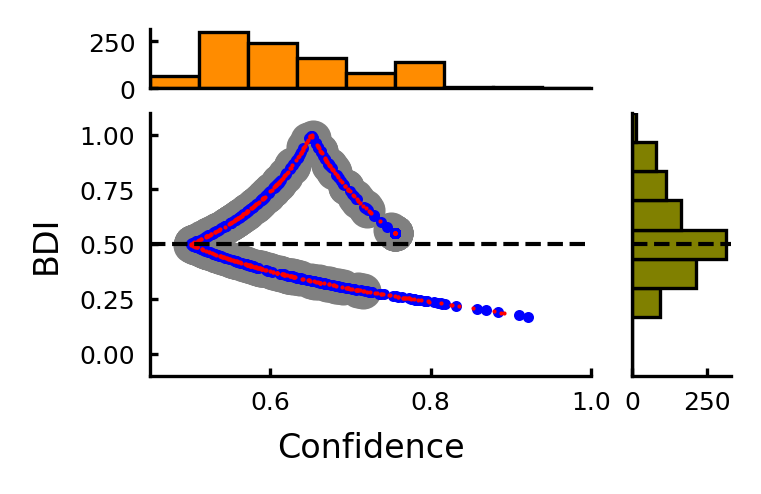

mdl3: last_layer_col=bdi_classifier_6, n_points=1000, acc=0.7490
Saved: /content/drive/MyDrive/AlexNet_Images/mdl4_BDI_last_layer_vs_conf_colored_correct_marginal_hist.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl4_BDI_last_layer_vs_conf_colored_correct_marginal_hist.png


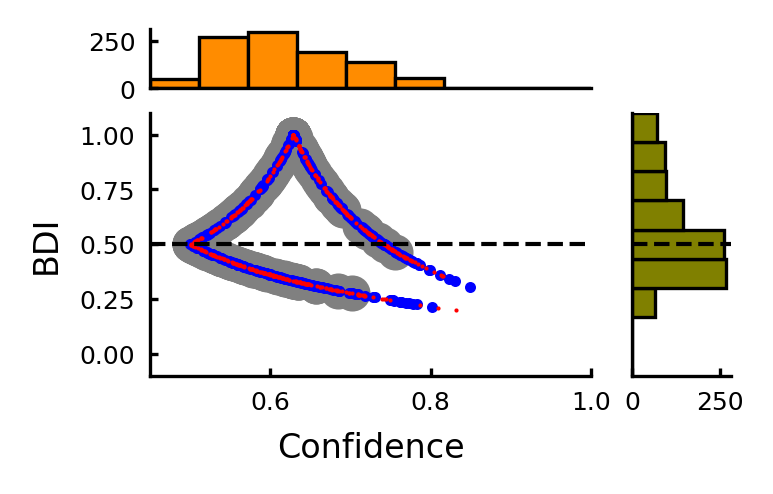

mdl4: last_layer_col=bdi_classifier_6, n_points=1000, acc=0.7410
Saved: /content/drive/MyDrive/AlexNet_Images/mdl5_BDI_last_layer_vs_conf_colored_correct_marginal_hist.eps
Saved: /content/drive/MyDrive/AlexNet_Images/mdl5_BDI_last_layer_vs_conf_colored_correct_marginal_hist.png


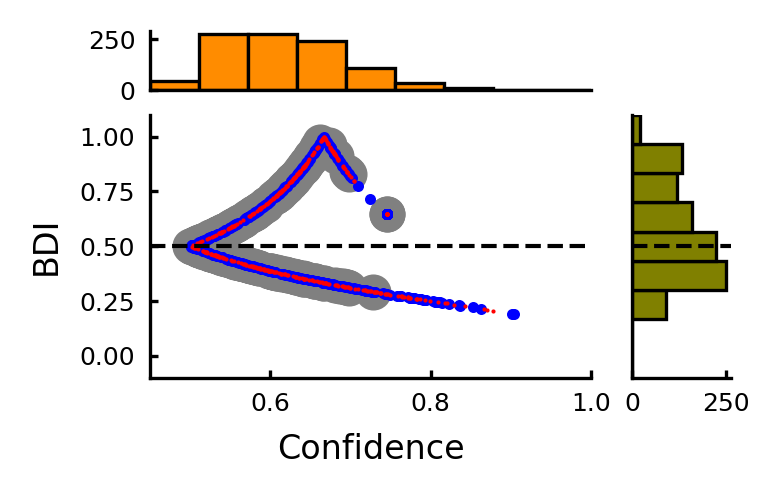

mdl5: last_layer_col=bdi_classifier_6, n_points=1000, acc=0.7600


In [12]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

save_fig = True
out_dir = "/content/drive/MyDrive/AlexNet_Images"

csv_paths = sorted(glob.glob(os.path.join(out_dir, "*_multilayer_bdi_redblue.csv")))

if len(csv_paths) != 5:
    print("Found:", len(csv_paths))
    print("\n".join([os.path.basename(p) for p in csv_paths]))
    raise ValueError("Expected 5 CSVs. Adjust out_dir/pattern, or filter to your 5 files.")


def get_use_from_path(path: str) -> str:
    return os.path.basename(path).replace("_multilayer_bdi_redblue.csv", "")


def layer_sort_key(colname: str):
    s = colname.replace("bdi_", "").replace(".", "_")

    m = re.match(r"^(features|classifier)_(\d+)$", s)
    if m:
        block, idx = m.group(1), int(m.group(2))
        group = 0 if block == "features" else 1
        return (group, idx, s)

    nums = re.findall(r"\d+", s)
    first_num = int(nums[0]) if nums else 10**9
    return (2, first_num, s)


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
X_LIM = (0.45, 1.0)
Y_LIM = (-0.1, 1.10)

X_BINS = np.linspace(X_LIM[0], X_LIM[1], 10)
Y_BINS = np.linspace(Y_LIM[0], Y_LIM[1], 10)

for path in csv_paths:
    USE = get_use_from_path(path)
    df = pd.read_csv(path)

    # --------------------------------------------------------
    # Required columns
    # --------------------------------------------------------
    for c in ["conf", "correct"]:
        if c not in df.columns:
            raise ValueError(f"{USE}: missing '{c}' column in {os.path.basename(path)}")

    # --------------------------------------------------------
    # Last-layer BDI column
    # --------------------------------------------------------
    layer_cols = [
        c for c in df.columns
        if c.startswith("bdi_") and c != "bdi_all_layers"
    ]

    if not layer_cols:
        raise ValueError(f"{USE}: no per-layer bdi_ columns found in {os.path.basename(path)}")

    layer_cols = sorted(layer_cols, key=layer_sort_key)
    last_layer_col = layer_cols[-1]

    # --------------------------------------------------------
    # Pull arrays
    # --------------------------------------------------------
    x = pd.to_numeric(df["conf"], errors="coerce").to_numpy(dtype=float).ravel()
    y = pd.to_numeric(df[last_layer_col], errors="coerce").to_numpy(dtype=float).ravel()
    acc = pd.to_numeric(df["correct"], errors="coerce").to_numpy(dtype=float).ravel()

    # trial parity: even -> red, odd -> blue
    trial_idx = np.arange(len(df))
    is_red_trial = trial_idx % 2 == 0
    is_blue_trial = ~is_red_trial

    # finite mask
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(acc)

    x_m = x[mask]
    y_m = y[mask]
    acc_m = acc[mask]

    red_m = is_red_trial[mask]
    blue_m = is_blue_trial[mask]

    # correct as binary
    correct_m = acc_m >= 0.5

    # color masks
    m_incorrect = ~correct_m
    m_red_ok = correct_m & red_m
    m_blue_ok = correct_m & blue_m

    overall_acc = float(correct_m.mean()) if correct_m.size else np.nan

    # ========================================================
    # Figure with marginal histograms
    # ========================================================
    fig = plt.figure(figsize=(2.5, 1.5), dpi=300)

    gs = GridSpec(
        2,
        2,
        width_ratios=[4.0, 0.9],
        height_ratios=[0.9, 4.0],
        wspace=0.15,
        hspace=0.15,
        figure=fig,
    )

    ax_histx = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0], sharex=ax_histx)
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

    # --------------------------------------------------------
    # Main scatter
    # --------------------------------------------------------
    ax.scatter(
        x_m[m_incorrect],
        y_m[m_incorrect],
        s=75,
        color="gray",
        alpha=1,
        linewidths=0,
        rasterized=True,
    )

    ax.scatter(
        x_m[m_blue_ok],
        y_m[m_blue_ok],
        s=7,
        color="blue",
        alpha=1,
        linewidths=0,
        rasterized=True,
    )

    ax.scatter(
        x_m[m_red_ok],
        y_m[m_red_ok],
        s=1,
        color="red",
        alpha=1,
        linewidths=0,
        rasterized=True,
    )

    ax.axhline(0.5, linestyle="--", color="black", linewidth=1)

    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_yticks(np.arange(0, 1.01, 0.25))

    ax.set_xlabel("Confidence", fontsize=8)
    ax.set_ylabel("BDI", fontsize=8)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        length=2,
        labelsize=6,
    )

    # --------------------------------------------------------
    # Top marginal histogram: confidence
    # --------------------------------------------------------
    ax_histx.hist(
        x_m,
        bins=X_BINS,
        color="darkorange",
        edgecolor="black",
        linewidth=0.8,
    )

    ax_histx.set_xlim(*X_LIM)
    ax_histx.tick_params(
        axis="x",
        which="both",
        bottom=False,
        labelbottom=False,
    )
    ax_histx.tick_params(
        axis="y",
        which="both",
        direction="in",
        length=2,
        labelsize=6,
    )

    ax_histx.spines["right"].set_visible(False)
    ax_histx.spines["top"].set_visible(False)

    # --------------------------------------------------------
    # Right marginal histogram: BDI
    # --------------------------------------------------------
    ax_histy.hist(
        y_m,
        bins=Y_BINS,
        orientation="horizontal",
        color="olive",
        edgecolor="black",
        linewidth=0.8,
    )

    # ax_histy.hist(
    #     y_m[m_blue_ok],
    #     bins=Y_BINS,
    #     histtype="step",
    #     orientation="horizontal",
    #     color="blue",
    #     linewidth=0.8,
    # )

    # ax_histy.hist(
    #     y_m[m_red_ok],
    #     bins=Y_BINS,
    #     histtype="step",
    #     orientation="horizontal",
    #     color="red",
    #     linewidth=0.8,
    # )

    ax_histy.axhline(0.5, linestyle="--", color="black", linewidth=1)

    ax_histy.set_ylim(*Y_LIM)
    ax_histy.tick_params(
        axis="y",
        which="both",
        left=False,
        labelleft=False,
    )
    ax_histy.tick_params(
        axis="x",
        which="both",
        direction="in",
        length=2,
        labelsize=6,
    )

    ax_histy.spines["right"].set_visible(False)
    ax_histy.spines["top"].set_visible(False)

    # --------------------------------------------------------
    # Final layout and save
    # --------------------------------------------------------
    if save_fig:
        out_base = os.path.join(
            out_dir,
            f"{USE}_BDI_last_layer_vs_conf_colored_correct_marginal_hist"
        )

        fig.savefig(
            out_base + ".eps",
            format="eps",
            bbox_inches="tight",
            pad_inches=0.02,
        )

        fig.savefig(
            out_base + ".png",
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.02,
        )

        print("Saved:", out_base + ".eps")
        print("Saved:", out_base + ".png")

    plt.show()

    print(
        f"{USE}: last_layer_col={last_layer_col}, "
        f"n_points={x_m.size}, acc={overall_acc:.4f}"
    )

In [ ]:
import torch
import torch.nn as nn

#----------------------------
# Estimate Layer-wise BDI
#----------------------------

def _get_conv_linear_layers(model: nn.Module):
    return [(name, m) for name, m in model.named_modules()
            if isinstance(m, (nn.Conv2d, nn.Linear))]

def _broadcast_bias(module: nn.Module, u: torch.Tensor) -> torch.Tensor:
    if getattr(module, "bias", None) is None or module.bias is None:
        return torch.zeros_like(u)
    b = module.bias
    if u.ndim == 2:      # Linear: (B, C)
        return b.view(1, -1).expand_as(u)
    if u.ndim == 4:      # Conv: (B, C, H, W)
        return b.view(1, -1, 1, 1).expand_as(u)
    return torch.zeros_like(u)

def multilayer_bdi_binary(
    model: nn.Module,
    x: torch.Tensor,
    y_true: torch.Tensor = None,              # (B,) long, optional
    margin_mode: str = "red_minus_blue",      # or "top1_minus_top2"
    red_class: int = 0,
    blue_class: int = 1,
    layers=None,
    return_extras: bool = True,
):
    """
    Multi-layer BDI for binary classifiers using gradient×component at each affine layer.

    Returns:
      bdi_by_layer: dict[layer_name] -> (B,) tensor
      bdi_all: (B,) tensor
      logits: (B,2) tensor
      pred: (B,) tensor
      conf: (B,) tensor (max softmax prob)
      correct: (B,) bool tensor or None
      extras (optional): dict with per-class probs/confidence and logit-based scores/margins.
    """
    model.eval()

    # Ensure autograd graph (even if params frozen)
    x = x.detach()
    x.requires_grad_(True)

    if layers is None:
        layers = _get_conv_linear_layers(model)

    store = {}
    hooks = []

    def make_hook(layer_name, layer_module):
        def hook_fn(m, inp, out):
            u = out
            if not u.requires_grad:
                raise RuntimeError(
                    f"{layer_name} output has requires_grad=False. "
                    f"Make sure you're NOT using torch.inference_mode() / torch.no_grad()."
                )
            u.retain_grad()
            u_bias = _broadcast_bias(layer_module, u)
            store[layer_name] = {"u": u, "u_bias": u_bias}
        return hook_fn

    for name, m in layers:
        hooks.append(m.register_forward_hook(make_hook(name, m)))

    # ----------------------------
    # Forward (with grad)
    # ----------------------------
    logits = model(x)  # expect (B,2)
    if logits.ndim != 2 or logits.shape[1] != 2:
        for h in hooks: h.remove()
        raise ValueError(f"Expected logits shape (B,2); got {tuple(logits.shape)}")

    # Prob-based confidence
    probs = torch.softmax(logits, dim=1)          # (B,2)
    pred = probs.argmax(dim=1)                    # (B,)
    conf = probs.max(dim=1).values                # (B,)
    conf_by_class = probs                         # (B,2)

    # Logit-based confidence / margins (binary)
    # class-1 vs class-0 (log-odds)
    logit_margin_10 = logits[:, 1] - logits[:, 0]                 # (B,)
    sigmoid_margin_10 = torch.sigmoid(logit_margin_10)            # (B,) in [0,1]
    abs_logit_margin_10 = logit_margin_10.abs()                   # (B,) distance to boundary in logit units

    # margins tied to (red_class, blue_class) selection
    logit_margin_red_blue = logits[:, red_class] - logits[:, blue_class]  # (B,)
    sigmoid_margin_red_blue = torch.sigmoid(logit_margin_red_blue)        # (B,)
    abs_logit_margin_red_blue = logit_margin_red_blue.abs()               # (B,)

    # Margin for backprop (the one that defines the decision margin decomposition)
    top2_vals = None
    top2_idx = None
    if margin_mode == "red_minus_blue":
        margin = logit_margin_red_blue                                  # signed
    elif margin_mode == "top1_minus_top2":
        top2_vals, top2_idx = torch.topk(logits, k=2, dim=1)            # (B,2)
        margin = top2_vals[:, 0] - top2_vals[:, 1]                      # >= 0
    else:
        for h in hooks: h.remove()
        raise ValueError("margin_mode must be 'red_minus_blue' or 'top1_minus_top2'")

    # ----------------------------
    # Backward
    # ----------------------------
    model.zero_grad(set_to_none=True)
    margin.sum().backward()

    # ----------------------------
    # Layerwise BDI
    # ----------------------------
    bdi_by_layer = {}
    abs_bias_sum = None
    abs_evid_sum = None

    for name, _ in layers:
        u = store[name]["u"]
        u_bias = store[name]["u_bias"]
        g = u.grad

        u_evid = u - u_bias
        dims = tuple(range(1, u.ndim))

        C_bias = (g * u_bias).sum(dim=dims)   # (B,)
        C_evid = (g * u_evid).sum(dim=dims)   # (B,)

        denom = C_bias.abs() + C_evid.abs()
        bdi_l = torch.where(denom > 0, C_bias.abs() / denom, torch.full_like(denom, 0.5))
        bdi_by_layer[name] = bdi_l.detach()

        if abs_bias_sum is None:
            abs_bias_sum = C_bias.abs()
            abs_evid_sum = C_evid.abs()
        else:
            abs_bias_sum = abs_bias_sum + C_bias.abs()
            abs_evid_sum = abs_evid_sum + C_evid.abs()

    denom_all = abs_bias_sum + abs_evid_sum
    bdi_all = torch.where(denom_all > 0, abs_bias_sum / denom_all, torch.full_like(denom_all, 0.5))

    correct = None
    if y_true is not None:
        correct = (pred == y_true)

    for h in hooks:
        h.remove()

    if return_extras:
        extras = {
            # prob space
            "probs": probs.detach(),                       # (B,2)
            "conf_by_class": conf_by_class.detach(),       # (B,2)

            # logits
            "logits_by_class": logits.detach(),            # (B,2)

            # logit-based “confidence” options
            "logit_margin_10": logit_margin_10.detach(),                   # (B,)
            "sigmoid_margin_10": sigmoid_margin_10.detach(),               # (B,)
            "abs_logit_margin_10": abs_logit_margin_10.detach(),           # (B,)

            "logit_margin_red_blue": logit_margin_red_blue.detach(),       # (B,)
            "sigmoid_margin_red_blue": sigmoid_margin_red_blue.detach(),   # (B,)
            "abs_logit_margin_red_blue": abs_logit_margin_red_blue.detach(),# (B,)

            # the exact margin used for BDI backprop
            "margin_used": margin.detach(),                                 # (B,)
        }

        if margin_mode == "top1_minus_top2":
            extras["top2_idx"] = top2_idx.detach()                          # (B,2)
            extras["top2_vals"] = top2_vals.detach()                        # (B,2)
            extras["logit_margin_top1_top2"] = (top2_vals[:, 0] - top2_vals[:, 1]).detach()
            extras["sigmoid_margin_top1_top2"] = torch.sigmoid(top2_vals[:, 0] - top2_vals[:, 1]).detach()
            extras["abs_logit_margin_top1_top2"] = (top2_vals[:, 0] - top2_vals[:, 1]).abs().detach()

        return (
            bdi_by_layer,
            bdi_all.detach(),
            logits.detach(),
            pred.detach(),
            conf.detach(),
            correct,
            extras
        )

    return bdi_by_layer, bdi_all.detach(), logits.detach(), pred.detach(), conf.detach(), correct


In [ ]:
import os, glob, re
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torchvision import transforms

#----------------------------
# Run BDI on model (UPDATED for extras return)
#----------------------------

def extract_last_int_from_path(p: str) -> int:
    base = os.path.splitext(os.path.basename(p))[0]
    nums = re.findall(r"\d+", base)
    if not nums:
        raise ValueError(f"No integer found in filename: {base}")
    return int(nums[-1])  # last integer token

# --- preprocessing: use whatever you used during training ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

img_save_dir = "/content/drive/MyDrive/AlexNet_Images/test_images"  # adjust
all_imgs = sorted(glob.glob(os.path.join(img_save_dir, "*.png")))
print("N images:", len(all_imgs))

BATCH = 10
layers = _get_conv_linear_layers(model)
layer_names = [n for n, _ in layers]

# accumulators
bdi_layers_accum = {name: [] for name in layer_names}
bdi_all_accum = []
pred_accum = []
conf_accum = []
correct_accum = []

# NEW accumulators for logits/probs + logit-based confidence
logits_accum = []                 # (N,2) raw logits
probs_accum = []                  # (N,2) softmax probs
conf_by_class_accum = []          # (N,2) same as probs (kept explicit)
logit_margin_10_accum = []        # (N,)
sigmoid_margin_10_accum = []      # (N,)
abs_logit_margin_10_accum = []    # (N,)

logit_margin_redblue_accum = []       # (N,)
sigmoid_margin_redblue_accum = []     # (N,)
abs_logit_margin_redblue_accum = []   # (N,)

# If you ever switch to top1_minus_top2, you can also store these:
logit_margin_top1top2_accum = []      # (N,) optional
sigmoid_margin_top1top2_accum = []    # (N,) optional
abs_logit_margin_top1top2_accum = []  # (N,) optional

MARGIN_MODE = "red_minus_blue"  # or "top1_minus_top2"

for i in range(0, len(all_imgs), BATCH):
    paths = all_imgs[i:i+BATCH]

    imgs = []
    y = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        imgs.append(transform(img))

        # ground truth rule (edit if different):
        # even index -> red(0), odd -> blue(1)
        idx = extract_last_int_from_path(p)
        y.append(0 if (idx % 2 == 0) else 1)

    x = torch.stack(imgs, dim=0).to(device)
    y_true = torch.tensor(y, dtype=torch.long, device=device)

    # UPDATED CALL: now returns extras (7th output)
    bdi_by_layer, bdi_all, z, pred, conf, correct, extras = multilayer_bdi_binary(
        model, x, y_true=y_true,
        margin_mode=MARGIN_MODE,
        red_class=0, blue_class=1,
        layers=layers,
        return_extras=True
    )

    # per-layer BDI
    for name in layer_names:
        bdi_layers_accum[name].append(bdi_by_layer[name].cpu().numpy())
    bdi_all_accum.append(bdi_all.cpu().numpy())

    # standard outputs
    pred_accum.append(pred.cpu().numpy())
    conf_accum.append(conf.cpu().numpy())
    correct_accum.append(correct.cpu().numpy())

    # NEW: logits / probs / logit-based measures from extras
    logits_accum.append(z.cpu().numpy())
    probs_accum.append(extras["probs"].cpu().numpy())
    conf_by_class_accum.append(extras["conf_by_class"].cpu().numpy())

    logit_margin_10_accum.append(extras["logit_margin_10"].cpu().numpy())
    sigmoid_margin_10_accum.append(extras["sigmoid_margin_10"].cpu().numpy())
    abs_logit_margin_10_accum.append(extras["abs_logit_margin_10"].cpu().numpy())

    logit_margin_redblue_accum.append(extras["logit_margin_red_blue"].cpu().numpy())
    sigmoid_margin_redblue_accum.append(extras["sigmoid_margin_red_blue"].cpu().numpy())
    abs_logit_margin_redblue_accum.append(extras["abs_logit_margin_red_blue"].cpu().numpy())

    if MARGIN_MODE == "top1_minus_top2":
        logit_margin_top1top2_accum.append(extras["logit_margin_top1_top2"].cpu().numpy())
        sigmoid_margin_top1top2_accum.append(extras["sigmoid_margin_top1_top2"].cpu().numpy())
        abs_logit_margin_top1top2_accum.append(extras["abs_logit_margin_top1_top2"].cpu().numpy())

# ----------------------------
# Stack to (N, ...)
# ----------------------------
bdi_all_np = np.concatenate(bdi_all_accum, axis=0)
pred_np = np.concatenate(pred_accum, axis=0)
conf_np = np.concatenate(conf_accum, axis=0)
correct_np = np.concatenate(correct_accum, axis=0)

bdi_layers_np = {name: np.concatenate(chunks, axis=0) for name, chunks in bdi_layers_accum.items()}

logits_np = np.concatenate(logits_accum, axis=0)              # (N,2)
probs_np = np.concatenate(probs_accum, axis=0)                # (N,2)
conf_by_class_np = np.concatenate(conf_by_class_accum, axis=0) # (N,2)

logit_margin_10_np = np.concatenate(logit_margin_10_accum, axis=0)              # (N,)
sigmoid_margin_10_np = np.concatenate(sigmoid_margin_10_accum, axis=0)          # (N,)
abs_logit_margin_10_np = np.concatenate(abs_logit_margin_10_accum, axis=0)      # (N,)

logit_margin_redblue_np = np.concatenate(logit_margin_redblue_accum, axis=0)          # (N,)
sigmoid_margin_redblue_np = np.concatenate(sigmoid_margin_redblue_accum, axis=0)      # (N,)
abs_logit_margin_redblue_np = np.concatenate(abs_logit_margin_redblue_accum, axis=0)  # (N,)

if MARGIN_MODE == "top1_minus_top2":
    logit_margin_top1top2_np = np.concatenate(logit_margin_top1top2_accum, axis=0)
    sigmoid_margin_top1top2_np = np.concatenate(sigmoid_margin_top1top2_accum, axis=0)
    abs_logit_margin_top1top2_np = np.concatenate(abs_logit_margin_top1top2_accum, axis=0)

print("BDI all layers:", bdi_all_np.shape)
print("Logits:", logits_np.shape, "Probs:", probs_np.shape)
print("Accuracy:", correct_np.mean(), f"({correct_np.sum()}/{correct_np.size})")

# ----------------------------
# Save to CSV (one row per image)
# ----------------------------
out_dir = "/content/drive/MyDrive/AlexNet_Images"
os.makedirs(out_dir, exist_ok=True)

# base columns
df = pd.DataFrame({
    "bdi_all_layers": bdi_all_np.astype(float),
    "pred": pred_np.astype(int),
    "conf": conf_np.astype(float),                 # max softmax prob
    "correct": correct_np.astype(int),

    # per-class logits
    "logit_red": logits_np[:, 0].astype(float),
    "logit_blue": logits_np[:, 1].astype(float),

    # per-class probs ("confidence for each option")
    "prob_red": probs_np[:, 0].astype(float),
    "prob_blue": probs_np[:, 1].astype(float),

    # logit-based confidences / margins
    "logit_margin_10": logit_margin_10_np.astype(float),                 # z1 - z0
    "sigmoid_margin_10": sigmoid_margin_10_np.astype(float),             # sigmoid(z1 - z0)
    "abs_logit_margin_10": abs_logit_margin_10_np.astype(float),         # |z1 - z0|

    "logit_margin_red_blue": logit_margin_redblue_np.astype(float),      # z_red - z_blue (same as above if red=0 blue=1)
    "sigmoid_margin_red_blue": sigmoid_margin_redblue_np.astype(float),
    "abs_logit_margin_red_blue": abs_logit_margin_redblue_np.astype(float),
})

# Optional top1-top2 margin columns if you switch modes
if MARGIN_MODE == "top1_minus_top2":
    df["logit_margin_top1_top2"] = logit_margin_top1top2_np.astype(float)
    df["sigmoid_margin_top1_top2"] = sigmoid_margin_top1top2_np.astype(float)
    df["abs_logit_margin_top1_top2"] = abs_logit_margin_top1top2_np.astype(float)

# add per-layer columns
for name, arr in bdi_layers_np.items():
    col = "bdi_" + name.replace(".", "_")
    df[col] = np.asarray(arr).astype(float)

csv_path = os.path.join(out_dir, f"{USE}_multilayer_bdi_redblue.csv")
df.to_csv(csv_path, index=False)

print("✅ Saved CSV:", csv_path)
print("CSV shape:", df.shape)


N images: 1000
BDI all layers: (1000,)
Logits: (1000, 2) Probs: (1000, 2)
Accuracy: 0.76 (760/1000)
✅ Saved CSV: /content/drive/MyDrive/AlexNet_Images/mdl5_multilayer_bdi_redblue.csv
CSV shape: (1000, 22)


mdl1: using last_layer_col=bdi_classifier_6
mdl1: n=1000 | mean=0.34953899231553076099032750789774581789970398 | std=0.2200 | IQR=0.2670
Saved: /content/drive/MyDrive/AlexNet_Images/mdl1_hist_BDI_last_layer.eps


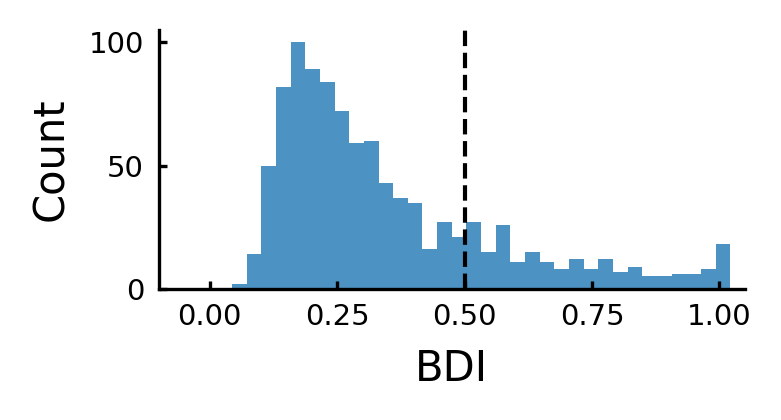

mdl2: using last_layer_col=bdi_classifier_6
mdl2: n=1000 | mean=0.36114111132174731011446056072600185871124268 | std=0.2547 | IQR=0.2672
Saved: /content/drive/MyDrive/AlexNet_Images/mdl2_hist_BDI_last_layer.eps


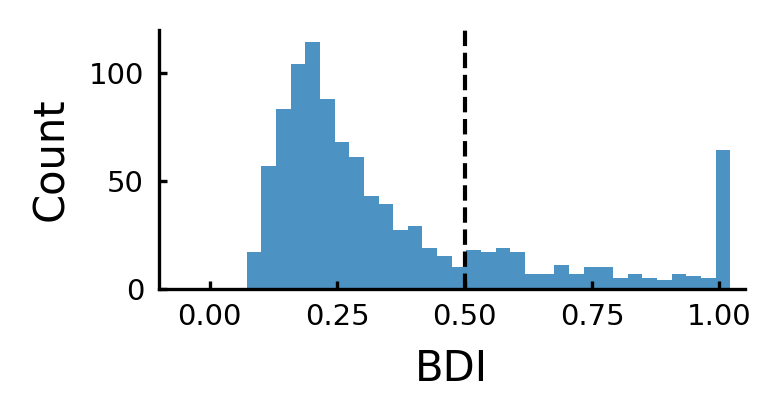

mdl3: using last_layer_col=bdi_classifier_6
mdl3: n=1000 | mean=0.54424457687139515815744061910663731396198273 | std=0.1875 | IQR=0.2649
Saved: /content/drive/MyDrive/AlexNet_Images/mdl3_hist_BDI_last_layer.eps


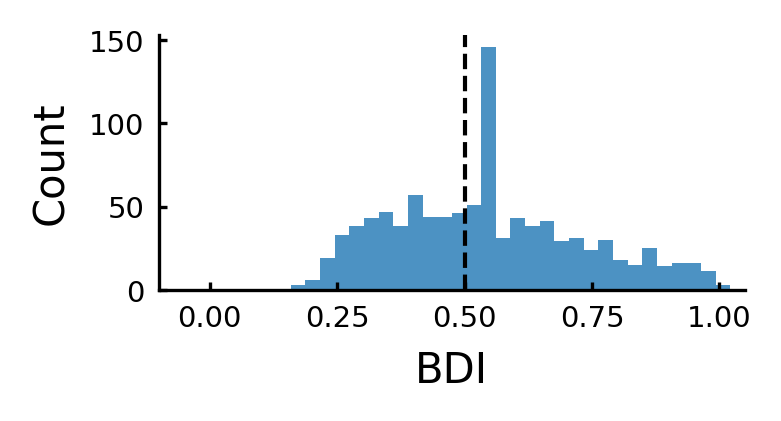

mdl4: using last_layer_col=bdi_classifier_6
mdl4: n=1000 | mean=0.56618096952140328781410971714649349451065063 | std=0.2150 | IQR=0.3148
Saved: /content/drive/MyDrive/AlexNet_Images/mdl4_hist_BDI_last_layer.eps


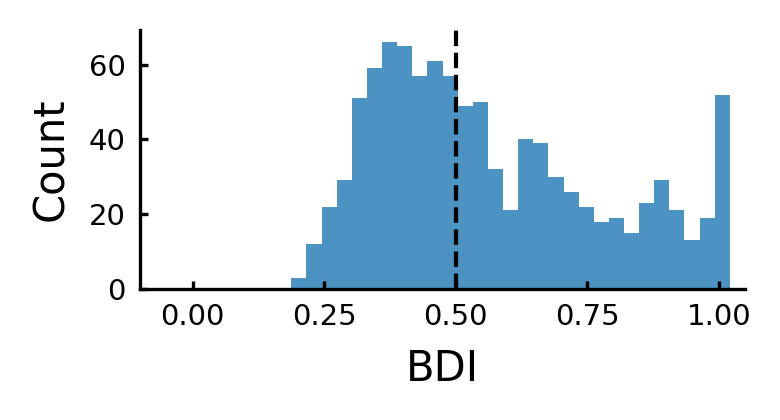

mdl5: using last_layer_col=bdi_classifier_6
mdl5: n=1000 | mean=0.56131339544057845536428885679924860596656799 | std=0.2100 | IQR=0.3427


Saved: /content/drive/MyDrive/AlexNet_Images/mdl5_hist_BDI_last_layer.eps


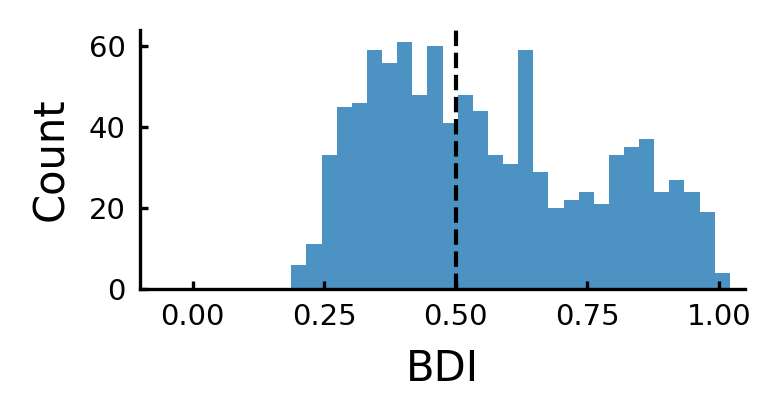

In [ ]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save_fig = True
out_dir = "/content/drive/MyDrive/AlexNet_Images"

csv_paths = sorted(glob.glob(os.path.join(out_dir, "*_multilayer_bdi_redblue.csv")))

if len(csv_paths) != 5:
    print("Found:", len(csv_paths))
    print("\n".join([os.path.basename(p) for p in csv_paths]))
    raise ValueError("Expected 5 CSVs. Adjust out_dir/pattern, or filter to your 5 files.")

def get_use_from_path(path: str) -> str:
    return os.path.basename(path).replace("_multilayer_bdi_redblue.csv", "")

def layer_sort_key(colname: str):
    s = colname.replace("bdi_", "").replace(".", "_")
    m = re.match(r"^(features|classifier)_(\d+)$", s)
    if m:
        block, idx = m.group(1), int(m.group(2))
        group = 0 if block == "features" else 1
        return (group, idx, s)
    nums = re.findall(r"\d+", s)
    first_num = int(nums[0]) if nums else 10**9
    return (2, first_num, s)

for path in csv_paths:
    USE = get_use_from_path(path)
    df = pd.read_csv(path)

    # last-layer BDI column
    layer_cols = [c for c in df.columns if c.startswith("bdi_") and c != "bdi_all_layers"]
    if not layer_cols:
        raise ValueError(f"{USE}: no per-layer bdi_ columns found in {os.path.basename(path)}")
    layer_cols = sorted(layer_cols, key=layer_sort_key)
    last_layer_col = layer_cols[-1]
    print(f"{USE}: using last_layer_col={last_layer_col}")

    # pull last-layer BDI
    y = pd.to_numeric(df[last_layer_col], errors="coerce").to_numpy(dtype=float).ravel()
    y = y[np.isfinite(y)]

    if y.size == 0:
        print(f"{USE}: no finite BDI values; skipping")
        continue

    # ---- summary stats ----
    mean_y = float(np.mean(y))
    std_y  = float(np.std(y, ddof=1)) if y.size > 1 else np.nan
    q25, q75 = np.percentile(y, [25, 75])
    iqr_y = float(q75 - q25)

    print(f"{USE}: n={y.size} | mean={mean_y:.44f} | std={std_y:.4f} | IQR={iqr_y:.4f}")

    # ---- histogram ----
    fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

    bins = np.linspace(-0.1, 1.05, 41)  # 40 bins over your prior BDI range
    ax.hist(y, bins=bins, alpha=0.8, linewidth=0)

    ax.axvline(0.5, linestyle="--", color="black", linewidth=1)
    ax.set_xlim(-0.1, 1.05)
    ax.set_xticks(np.arange(0, 1.01, 0.25))

    ax.set_xlabel("BDI", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis="both", which="both", direction="in", length=2, labelsize=7)

    fig.tight_layout()

    if save_fig:
        out_fig = os.path.join(out_dir, f"{USE}_hist_BDI_last_layer.eps")
        fig.savefig(out_fig, bbox_inches="tight", pad_inches=0.02)
        print("Saved:", out_fig)

    plt.show()
